In [11]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [12]:
import session_info
session_info.show()

/home/ever/anaconda3/lib/python3.13/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


In [13]:


# Loading and examining the dataset
penguins_df = pd.read_csv("../data/penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [14]:
# Checking for null values
penguins_df.dropna(how='all')
penguins_df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [15]:
# Creating dummys for sex na dropping
penguins_df = pd.concat([penguins_df, pd.get_dummies(penguins_df['sex'])],axis = 1)
peguins_df = penguins_df.drop(columns = 'sex',inplace=True)

In [16]:
# Check if everything is ok with data
penguins_df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,FEMALE,MALE
0,39.1,18.7,181.0,3750.0,False,True
1,39.5,17.4,186.0,3800.0,True,False
2,40.3,18.0,195.0,3250.0,True,False
3,36.7,19.3,193.0,3450.0,True,False
4,39.3,20.6,190.0,3650.0,False,True
...,...,...,...,...,...,...
327,47.2,13.7,214.0,4925.0,True,False
328,46.8,14.3,215.0,4850.0,True,False
329,50.4,15.7,222.0,5750.0,False,True
330,45.2,14.8,212.0,5200.0,True,False


In [17]:
# Writing or K-means cluster
scaler = StandardScaler()
X = scaler.fit_transform(penguins_df)
penguins_processed = pd.DataFrame(data=X, columns= penguins_df.columns)
penguins_processed.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,FEMALE,MALE
0,-0.903906,0.790360,-1.425342,-0.566948,-0.993994,0.993994
1,-0.830434,0.126187,-1.068577,-0.504847,1.006042,-1.006042
2,-0.683490,0.432728,-0.426399,-1.187953,1.006042,-1.006042
3,-1.344738,1.096901,-0.569105,-0.939551,1.006042,-1.006042
4,-0.867170,1.761074,-0.783164,-0.691149,-0.993994,0.993994


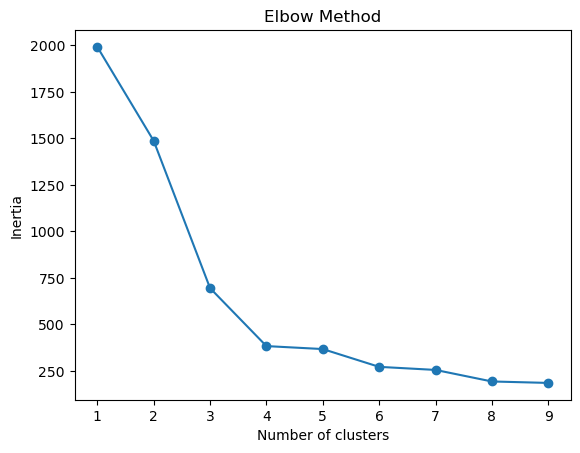

In [18]:
# Detect optimal clusters 
clusters = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k,random_state=42).fit(penguins_processed)
    clusters.append(kmeans.inertia_)
plt.plot(range(1,10),clusters,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.savefig('../images/elbow.png')
plt.show()
n_clusters = 4

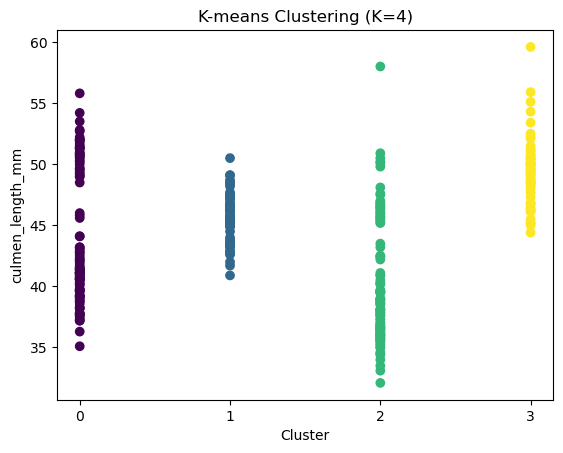

In [19]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(penguins_processed)
penguins_df['label'] = kmeans.labels_

# and visualize the clusters (here for the 'culmen_length_mm' column)
plt.scatter(penguins_df['label'], penguins_df['culmen_length_mm'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('Cluster')
plt.ylabel('culmen_length_mm')
plt.xticks(range(int(penguins_df['label'].min()), int(penguins_df['label'].max()) + 1))
plt.title(f'K-means Clustering (K={n_clusters})')

plt.savefig('../images/kmeans.png')
plt.show()

In [20]:
# Step - create final `stat_penguins` DataFrame
numeric_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm','label']
stat_penguins = penguins_df[numeric_columns].groupby('label').mean()
stat_penguins

,culmen_length_mm,culmen_depth_mm,flipper_length_mm
label,,,
0,43.878302,19.111321,194.764151
1,45.563793,14.237931,212.706897
2,40.217757,17.611215,189.046729
3,49.473770,15.718033,221.540984
